In [1]:
%loadlibs
from scipy.integrate import solve_ivp
torch.set_default_dtype(torch.float32)
torch.set_default_device('mps')

Loaded libraries:
	- numpy (np)
	- matplotlib.pyplot (plt)
	- torch
	- torch.nn (nn)
	- torch.optim (optim)
	- tqdm


Let us take a simple ODE in three dimensions:
\begin{equation}
    \begin{align}
        &\frac{\partial x}{\partial t} = \alpha y - xz\\
        &\frac{\partial y}{\partial t} = -\beta x + yz\\
        &\frac{\partial z}{\partial t} = \gamma y + x - z
    \end{align}
\end{equation}
with $\alpha = 4.$, $\beta = 2.$, and $\gamma = \frac12$.

In [2]:
ALPHA = 4.
BETA = 2.
GAMMA = 1/2

def system(t, state):
    x, y, z = state
    dxdt = ALPHA * y - x * z
    dydt = -BETA * x + y * z
    dzdt = GAMMA * y + x - z
    return [dxdt, dydt, dzdt]

In [3]:
def integrate(x0, y0, z0, t0, tmax):
    t_span = (t0, tmax)
    t_eval = np.linspace(0.0, tmax, 1000)
    sol = solve_ivp(
        system, t_span, [x0, y0, z0],
        t_eval=t_eval,
        method="RK45",
        rtol=1e-9, atol=1e-9,
        dense_output=False)
    return sol.t, sol.y[0], sol.y[1], sol.y[2]

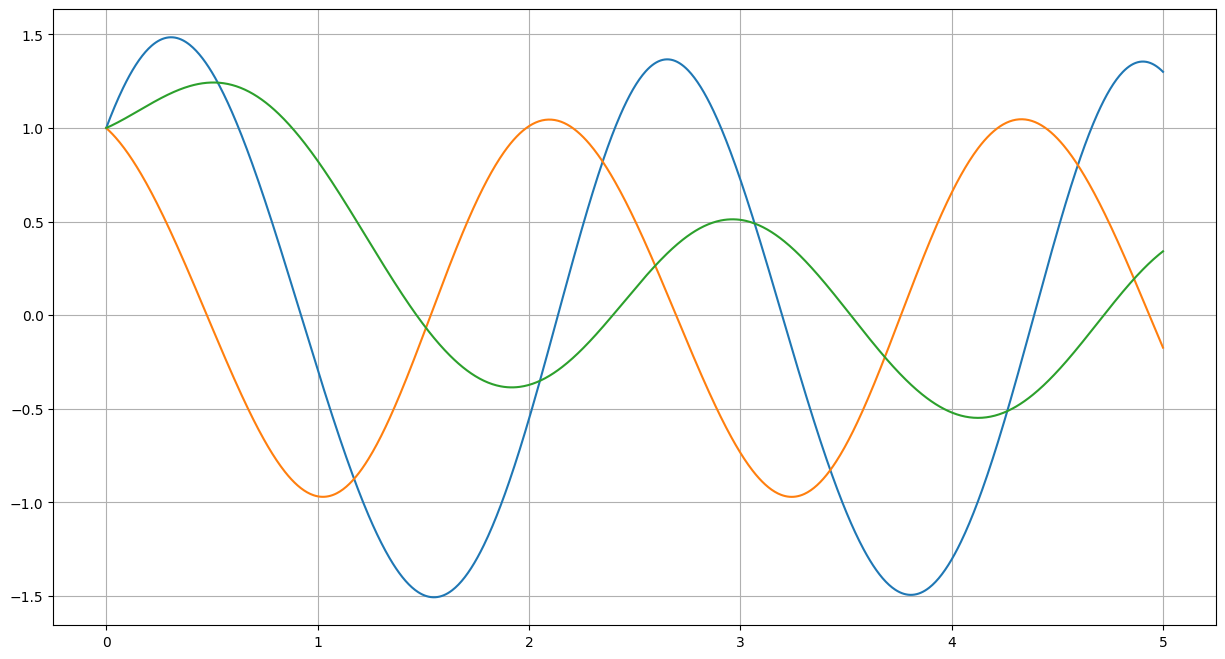

In [4]:
x0 = 1.
y0 = 1.
z0 = 1.
t0 = 0.
tmax = 5.
t_ref, x_ref, y_ref, z_ref = integrate(x0, y0, z0, t0, tmax)
plt.figure(figsize=(15, 8))
plt.plot(t_ref, x_ref)
plt.plot(t_ref, y_ref)
plt.plot(t_ref, z_ref)
plt.grid()
plt.show()

In [5]:
class PINN(nn.Module):
    def __init__(self, layer_size, n_hidden_layers=4):
        super().__init__()
        self.layer_size = layer_size
        self.n_hidden_layers = n_hidden_layers
        self.l1 = nn.Linear(4, self.layer_size)
        self.h = nn.ModuleList([nn.Linear(self.layer_size, self.layer_size) for _ in range(self.n_hidden_layers)])
        self.l2 = nn.Linear(self.layer_size, 3)
        self.activation = nn.SiLU()

    def apply_ic(self, t, raw_out, t_0, ic):
        a, b, c = ic[:, 0:1], ic[:, 1:2], ic[:, 2:3]
        envelope = t-t_0
        x = a + envelope * raw_out[..., 0:1]
        y = b + envelope * raw_out[..., 1:2]
        z = c + envelope * raw_out[..., 2:3]
        return torch.cat([x, y, z], dim=-1)
    
    def forward(self, t, t_0, ic):
        a, b, c = ic[:, 0:1], ic[:, 1:2], ic[:, 2:3]
        x = self.activation(self.l1(torch.concatenate([a, b, c, t], axis=-1)))
        for i in range(self.n_hidden_layers):
            x = self.activation(self.h[i](x))
        return self.apply_ic(t, self.l2(x), t_0, ic)

def pde_loss(outputs, t):
    x, y, z = outputs[..., 0:1], outputs[..., 1:2], outputs[..., 2:3]
    dx_dt = torch.autograd.grad(x, t, torch.ones_like(t), create_graph=True)[0]
    dy_dt = torch.autograd.grad(y, t, torch.ones_like(t), create_graph=True)[0]
    dz_dt = torch.autograd.grad(z, t, torch.ones_like(t), create_graph=True)[0]
    rht1 = ALPHA * y - x * z
    rht2 = -BETA * x + y * z
    rht3 = GAMMA * y + x - z
    return (((dx_dt-rht1)**2) + ((dy_dt-rht2)**2) + ((dz_dt-rht3)**2)).mean()
    
model = PINN(layer_size=64, n_hidden_layers=4)
optimizer = optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.8, patience=500, min_lr=1e-5)
n_points = 2**12
t_0 = torch.tensor(np.array(t0), dtype=torch.float32)
t_max = torch.tensor(np.array(tmax), dtype=torch.float32)

n_epochs = 5000
for stage in (pbar:=tqdm(range(n_epochs))):
    optimizer.zero_grad()
    t = t_0 + torch.rand((n_points, 1), requires_grad=True) * t_max
    ic = (torch.rand((n_points, 3), requires_grad=True) - 0.5) * 3
    outputs = model(t, t_0, ic)
    loss = pde_loss(outputs, t)
    loss.backward()
    optimizer.step()
    scheduler.step(loss.item())
    pbar.set_description(f"Loss: {loss.item():.5e} - lr: {optimizer.param_groups[0]['lr']:.3e}")

  0%|          | 0/5000 [00:00<?, ?it/s]

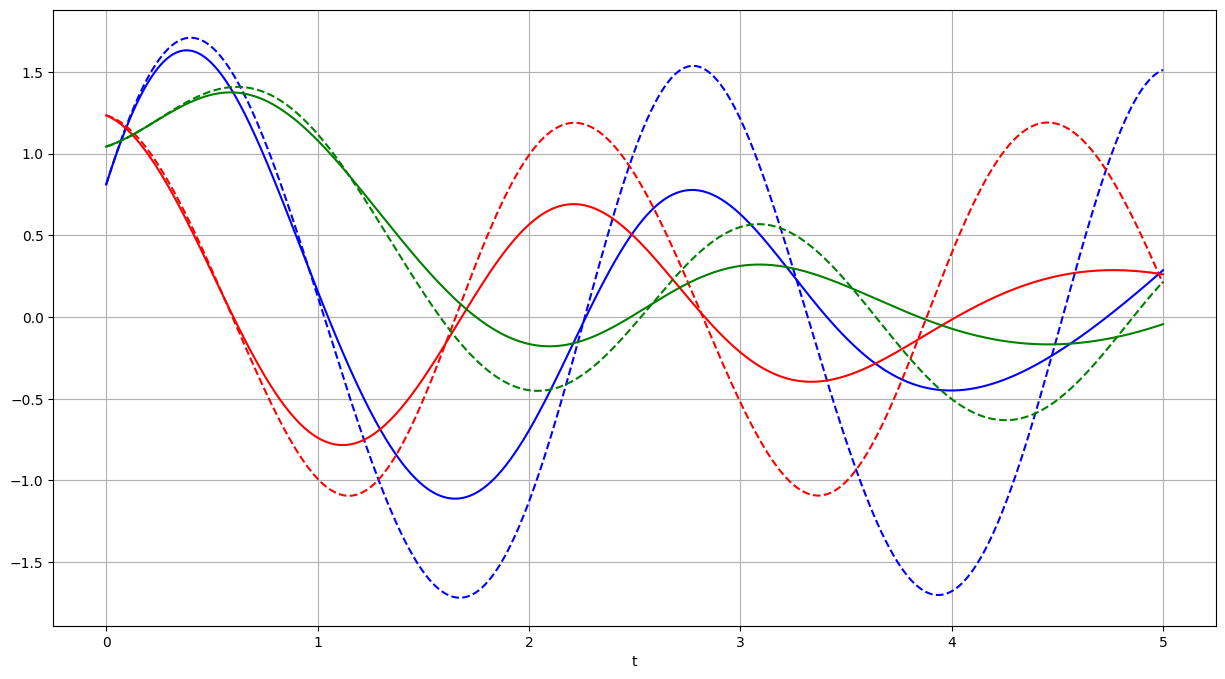

In [6]:
idx = 3
with torch.no_grad():
    t = torch.linspace(0, t_max, 1000).unsqueeze(-1)
    outputs = model(t, t_0, ic[idx:idx+1].repeat(1000, 1)).cpu().detach()
    x, y, z = outputs[..., 0:1], outputs[..., 1:2], outputs[..., 2:3]
t_ref, x_ref, y_ref, z_ref = integrate(*ic[idx].cpu().detach(), t_0.item(), t_max.item())
plt.figure(figsize=(15, 8))
plt.plot(t.cpu(), x.cpu(), color='blue')
plt.plot(t_ref, x_ref, linestyle='--', color='blue')
plt.plot(t.cpu(), y.cpu(), color='red')
plt.plot(t_ref, y_ref, linestyle='--', color='red')
plt.plot(t.cpu(), z.cpu(), color='green')
plt.plot(t_ref, z_ref, linestyle='--', color='green')
plt.xlabel('t')
plt.grid()
plt.show()